# Cookie Cats A/B Test — 가설 검정

**비즈니스 질문:** Gate를 레벨 30에서 레벨 40으로 옮기면 D7 리텐션이 유의미하게 달라지는가?

| 가설 | 내용 |
|---|---|
| H₀ (귀무가설) | 게이트 위치는 D7 리텐션에 영향을 미치지 않는다: π_gate30 = π_gate40 |
| H₁ (대립가설) | 게이트 위치는 D7 리텐션에 영향을 미친다: π_gate30 ≠ π_gate40 |
| 유의수준 α | 0.05 |

**분석 순서:** ① 카이제곱 검정 → ② Two-proportion Z-test → ③ Bootstrap

## 1. 데이터 불러오기 & 전처리 (EDA와 동일)

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib import font_manager as fm
from scipy import stats

# 한글 폰트 자동 탐지 (OS 무관)
preferred_fonts = [
    'AppleGothic', 'Malgun Gothic', 'NanumGothic',
    'Noto Sans CJK KR', 'Arial Unicode MS',
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
font = next((name for name in preferred_fonts if name in available_fonts), 'DejaVu Sans')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = font
plt.rcParams['font.sans-serif'] = [font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if font == 'DejaVu Sans':
    warnings.filterwarnings('ignore', message=r'Glyph .* missing from current font\.')

# 데이터 로드
df_raw = pd.read_csv('../data/cookie_cats.csv')

# --- EDA 동일 전처리 ---
OUTLIER_UPPER = 30_000
df = df_raw[df_raw['sum_gamerounds'] <= OUTLIER_UPPER].copy()  # 극단 이상치 제거
df = df[df['sum_gamerounds'] > 0].copy()                        # 0라운드 유저 제거

print(f"원본         : {len(df_raw):>7,}명")
print(f"이상치 제거  : {(df_raw['sum_gamerounds'] > OUTLIER_UPPER).sum():>7,}명 제거")
print(f"0라운드 제거 : {(df_raw['sum_gamerounds'] == 0).sum():>7,}명 제거")
print(f"최종 분석 수 : {len(df):>7,}명")
print(f"사용 폰트    : {font}")
df['version'].value_counts()

원본         :  90,189명
이상치 제거  :       1명 제거
0라운드 제거 :   3,994명 제거
최종 분석 수 :  86,194명
사용 폰트    : AppleGothic


version
gate_40    43432
gate_30    42762
Name: count, dtype: int64

## 2. 기술 통계 — 분할표 (Contingency Table)

In [2]:
gate30 = df[df['version'] == 'gate_30']
gate40 = df[df['version'] == 'gate_40']

n30 = len(gate30)
n40 = len(gate40)

# D7 Retention 집계
r30_7 = gate30['retention_7'].sum()
r40_7 = gate40['retention_7'].sum()

p30 = r30_7 / n30
p40 = r40_7 / n40

# 분할표
ct = pd.DataFrame({
    'Retained (True)' : [r30_7,        r40_7       ],
    'Churned (False)' : [n30 - r30_7,  n40 - r40_7 ],
    'Total'           : [n30,          n40          ],
}, index=['gate_30', 'gate_40'])

print('=== 분할표 (D7 Retention) ===')
print(ct.to_string())
print()
print(f'gate_30 D7 Retention     : {p30*100:.4f}%  ({r30_7:,}/{n30:,})')
print(f'gate_40 D7 Retention     : {p40*100:.4f}%  ({r40_7:,}/{n40:,})')
print(f'차이 (gate_30 - gate_40) : {(p30 - p40)*100:+.4f}%p')

=== 분할표 (D7 Retention) ===
         Retained (True)  Churned (False)  Total
gate_30             8485            34277  42762
gate_40             8266            35166  43432

gate_30 D7 Retention     : 19.8424%  (8,485/42,762)
gate_40 D7 Retention     : 19.0321%  (8,266/43,432)
차이 (gate_30 - gate_40) : +0.8103%p


## 3. 카이제곱 검정 (Chi-square Test)

범주형 변수(그룹) × 이진 변수(리텐션)의 **독립성 검정**.

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

- H₀: gate 위치와 D7 리텐션은 독립이다 (π_30 = π_40)
- 조건: 모든 기대빈도 ≥ 5 (대규모 데이터이므로 충족 예상)

In [3]:
ct_vals = ct[['Retained (True)', 'Churned (False)']].values

chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(ct_vals)

print('=== 카이제곱 검정 결과 ===')
print(f'chi2 통계량 : {chi2_stat:.6f}')
print(f'p-value     : {p_chi2:.6f}')
print(f'자유도      : {dof}')
print()
print('기대빈도:')
print(pd.DataFrame(expected, index=['gate_30', 'gate_40'],
                   columns=['E_Retained', 'E_Churned']).round(2))
print()
if p_chi2 < 0.05:
    print(f'p = {p_chi2:.4f} < alpha 0.05  ->  H0 기각')
    print('  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.')
else:
    print(f'p = {p_chi2:.4f} >= alpha 0.05  ->  H0 채택')

=== 카이제곱 검정 결과 ===
chi2 통계량 : 8.984878
p-value     : 0.002722
자유도      : 1

기대빈도:
         E_Retained  E_Churned
gate_30      8310.4    34451.6
gate_40      8440.6    34991.4

p = 0.0027 < alpha 0.05  ->  H0 기각
  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.


## 4. Two-proportion Z-test

비율 차이에 대한 정규근사 검정. 표본이 충분히 클 때 카이제곱과 동등한 결과를 제공하며,  
**신뢰구간(CI)** 을 직접 산출할 수 있다는 장점이 있다.

$$Z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}$$

합동 비율 $\hat{p} = \dfrac{X_1 + X_2}{n_1 + n_2}$

=== Two-proportion Z-test 결과 ===
Z 통계량             : 3.006087
p-value              : 0.002646
95% CI (p30 - p40)  : [0.2820%p, 1.3387%p]

p = 0.0026 < alpha 0.05  ->  H0 기각
  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.
  95% CI 전체가 0 초과 -> gate_30의 D7 리텐션이 유의미하게 높다.


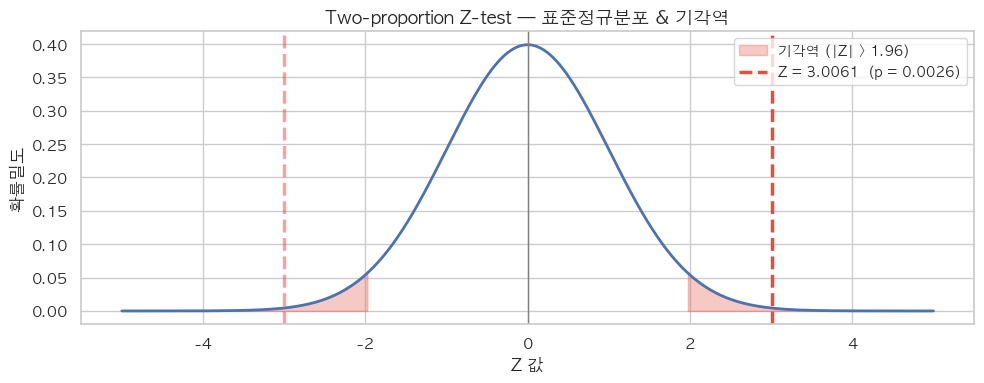

In [4]:
# 합동 비율 (귀무가설 하)
p_pool = (r30_7 + r40_7) / (n30 + n40)
se_pooled = np.sqrt(p_pool * (1 - p_pool) * (1/n30 + 1/n40))

z_stat = (p30 - p40) / se_pooled
p_z    = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # 양측

# 95% 신뢰구간 (비합동 SE)
se_diff = np.sqrt(p30*(1-p30)/n30 + p40*(1-p40)/n40)
z_crit  = stats.norm.ppf(0.975)
ci_lo   = (p30 - p40) - z_crit * se_diff
ci_hi   = (p30 - p40) + z_crit * se_diff

print('=== Two-proportion Z-test 결과 ===')
print(f'Z 통계량             : {z_stat:.6f}')
print(f'p-value              : {p_z:.6f}')
print(f'95% CI (p30 - p40)  : [{ci_lo*100:.4f}%p, {ci_hi*100:.4f}%p]')
print()
if p_z < 0.05:
    print(f'p = {p_z:.4f} < alpha 0.05  ->  H0 기각')
    print('  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.')
    if ci_lo > 0:
        print('  95% CI 전체가 0 초과 -> gate_30의 D7 리텐션이 유의미하게 높다.')
else:
    print(f'p = {p_z:.4f} >= alpha 0.05  ->  H0 채택')

# 시각화: 표준정규분포 위에 Z 통계량 표시
x = np.linspace(-5, 5, 500)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, color='#4C72B0', linewidth=2)
ax.fill_between(x, y, where=(x <= -z_crit), color='#e74c3c', alpha=0.3, label=f'기각역 (|Z| > {z_crit:.2f})')
ax.fill_between(x, y, where=(x >=  z_crit), color='#e74c3c', alpha=0.3)
ax.axvline( z_stat, color='#e74c3c', linestyle='--', linewidth=2.5,
            label=f'Z = {z_stat:.4f}  (p = {p_z:.4f})')
ax.axvline(-z_stat, color='#e74c3c', linestyle='--', linewidth=2.5, alpha=0.5)
ax.axvline(0, color='grey', linewidth=1, linestyle='-')
ax.set_xlabel('Z 값', fontsize=12)
ax.set_ylabel('확률밀도', fontsize=12)
ax.set_title('Two-proportion Z-test — 표준정규분포 & 기각역', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Bootstrap 검정

분포 가정 없이 재표본 추출(복원 추출)로 표본분포를 직접 추정.

1. gate_30 / gate_40 각각에서 복원 추출 → D7 리텐션 차이 δ* 계산
2. 10,000회 반복 → 부트스트랩 분포 구축
3. **95% CI**: 부트스트랩 분포의 2.5th ~ 97.5th 백분위수
4. **p-value**: 귀무가설(차이 = 0) 중심으로 이동한 분포에서 관찰값보다 극단적인 비율

In [5]:
np.random.seed(42)
N_BOOTSTRAP = 10_000

ret_30 = gate30['retention_7'].values.astype(int)
ret_40 = gate40['retention_7'].values.astype(int)

boot_diffs = np.array([
    np.random.choice(ret_30, size=len(ret_30), replace=True).mean() -
    np.random.choice(ret_40, size=len(ret_40), replace=True).mean()
    for _ in range(N_BOOTSTRAP)
])

observed_diff = p30 - p40

# 95% 신뢰구간 (백분위수 방법)
ci_boot_lo, ci_boot_hi = np.percentile(boot_diffs, [2.5, 97.5])

# p-value: 귀무가설 중심으로 이동 후 관찰값 이상 극단치 비율
boot_null = boot_diffs - boot_diffs.mean()
p_boot    = np.mean(np.abs(boot_null) >= np.abs(observed_diff))

print('=== Bootstrap 검정 결과 ===')
print(f'반복 횟수             : {N_BOOTSTRAP:,}회')
print(f'관찰된 차이 (p30-p40) : {observed_diff*100:+.4f}%p')
print(f'Bootstrap 평균 차이   : {boot_diffs.mean()*100:+.4f}%p')
print(f'Bootstrap 표준편차    : {boot_diffs.std()*100:.4f}%p')
print(f'95% CI                : [{ci_boot_lo*100:.4f}%p, {ci_boot_hi*100:.4f}%p]')
print(f'Bootstrap p-value     : {p_boot:.4f}')
print()
if p_boot < 0.05:
    print(f'p = {p_boot:.4f} < alpha 0.05  ->  H0 기각')
    print('  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.')
    if ci_boot_lo > 0:
        print('  95% CI 전체가 0 초과 -> gate_30의 D7 리텐션이 유의미하게 높다.')
else:
    print(f'p = {p_boot:.4f} >= alpha 0.05  ->  H0 채택')

=== Bootstrap 검정 결과 ===
반복 횟수             : 10,000회
관찰된 차이 (p30-p40) : +0.8103%p
Bootstrap 평균 차이   : +0.8076%p
Bootstrap 표준편차    : 0.2723%p
95% CI                : [0.2686%p, 1.3507%p]
Bootstrap p-value     : 0.0033

p = 0.0033 < alpha 0.05  ->  H0 기각
  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.
  95% CI 전체가 0 초과 -> gate_30의 D7 리텐션이 유의미하게 높다.


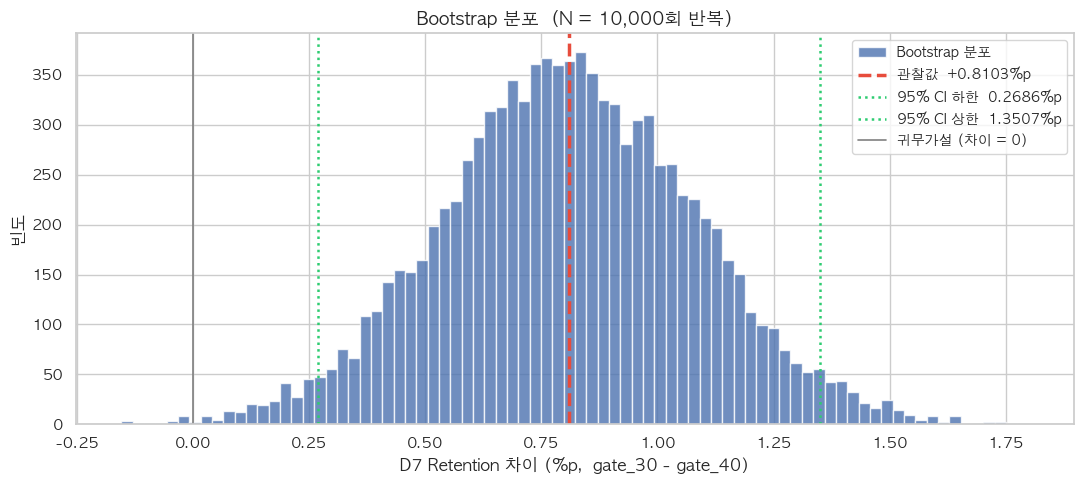

In [6]:
# 부트스트랩 분포 시각화
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(boot_diffs * 100, bins=80, color='#4C72B0', edgecolor='white', alpha=0.8,
        label='Bootstrap 분포')
ax.axvline(observed_diff  * 100, color='#e74c3c', linewidth=2.5, linestyle='--',
           label=f'관찰값  {observed_diff*100:+.4f}%p')
ax.axvline(ci_boot_lo * 100, color='#2ecc71', linewidth=1.8, linestyle=':',
           label=f'95% CI 하한  {ci_boot_lo*100:.4f}%p')
ax.axvline(ci_boot_hi * 100, color='#2ecc71', linewidth=1.8, linestyle=':',
           label=f'95% CI 상한  {ci_boot_hi*100:.4f}%p')
ax.axvline(0, color='grey', linewidth=1.2, linestyle='-', label='귀무가설 (차이 = 0)')

ax.set_xlabel('D7 Retention 차이 (%p,  gate_30 - gate_40)', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title(f'Bootstrap 분포  (N = {N_BOOTSTRAP:,}회 반복)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 6. 검정 결과 종합

In [7]:
summary = pd.DataFrame({
    '검정 방법'    : ['카이제곱 검정', 'Two-proportion Z-test', 'Bootstrap'],
    '통계량'       : [f'chi2={chi2_stat:.4f}', f'Z={z_stat:.4f}', f'diff={observed_diff*100:+.4f}%p'],
    'p-value'      : [f'{p_chi2:.6f}', f'{p_z:.6f}', f'{p_boot:.4f}'],
    'H0 기각 여부' : [
        '기각 (p < 0.05)' if p_chi2 < 0.05 else '채택',
        '기각 (p < 0.05)' if p_z    < 0.05 else '채택',
        '기각 (p < 0.05)' if p_boot < 0.05 else '채택',
    ],
    '95% CI'       : [
        '-',
        f'[{ci_lo*100:.4f}%p, {ci_hi*100:.4f}%p]',
        f'[{ci_boot_lo*100:.4f}%p, {ci_boot_hi*100:.4f}%p]',
    ],
})

print('=== 가설 검정 결과 종합 ===')
print(summary.to_string(index=False))
print()
print('=== 비즈니스 결론 ===')
print(f'gate_30 D7 Retention     : {p30*100:.4f}%')
print(f'gate_40 D7 Retention     : {p40*100:.4f}%')
print(f'차이 (gate_30 - gate_40) : {(p30 - p40)*100:+.4f}%p')
print()
if p_chi2 < 0.05 and p_z < 0.05 and p_boot < 0.05:
    print('세 가지 검정 모두 H0 기각')
    print('gate_30(대조군)의 D7 리텐션이 gate_40(실험군)보다 통계적으로 유의미하게 높다.')
    print('-> Gate를 레벨 40으로 옮기면 D7 리텐션이 감소한다. gate_30 유지를 권장한다.')
else:
    print('검정 결과가 일치하지 않음 — 개별 결과를 검토할 것')

=== 가설 검정 결과 종합 ===
                검정 방법            통계량  p-value      H0 기각 여부               95% CI
              카이제곱 검정    chi2=8.9849 0.002722 기각 (p < 0.05)                    -
Two-proportion Z-test       Z=3.0061 0.002646 기각 (p < 0.05) [0.2820%p, 1.3387%p]
            Bootstrap diff=+0.8103%p   0.0033 기각 (p < 0.05) [0.2686%p, 1.3507%p]

=== 비즈니스 결론 ===
gate_30 D7 Retention     : 19.8424%
gate_40 D7 Retention     : 19.0321%
차이 (gate_30 - gate_40) : +0.8103%p

세 가지 검정 모두 H0 기각
gate_30(대조군)의 D7 리텐션이 gate_40(실험군)보다 통계적으로 유의미하게 높다.
-> Gate를 레벨 40으로 옮기면 D7 리텐션이 감소한다. gate_30 유지를 권장한다.
